In [56]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

from generate_chunks import load_data
from train_models import ModelTrainer
from failure_detection import print_failures, simple_lowpass_filter
from os.path import exists

if not exists('data/pt1_tcn_output.npy'):

    model_name = 'PT1_TCN'
    model = ModelTrainer(f'configs/{model_name}.json').fit()
    train_chunks, training_chunk_dates, test_chunks, test_chunk_dates = load_data(version=model.version, scaler=model.scaler)

    val_size = int(0.3 * len(train_chunks))
    train_errors = model.calc_loss(train_chunks[-val_size:], train_chunks[-val_size:], average=False).mean(axis=(1,2))
    test_errors_raw = model.calc_loss(test_chunks, test_chunks, average=False)
    test_errors = test_errors_raw.mean(axis=(1,2))

    q99 = np.quantile(train_errors, [0.99])
    anom = 2*q99

    binary_output = (test_errors > anom).astype(np.int8)
    output = simple_lowpass_filter(binary_output, 0.1)
    np.save('data/pt1_tcn_output.npy', output.squeeze())

    failures = (output > 0.5).astype(np.int8)
    print_failures(test_chunk_dates, failures)
else:
    with open('data/pt1_test_chunk_dates.pkl', 'rb') as f:
        test_chunk_dates = pickle.load(f)
    output = np.load('data/pt1_tcn_output.npy')

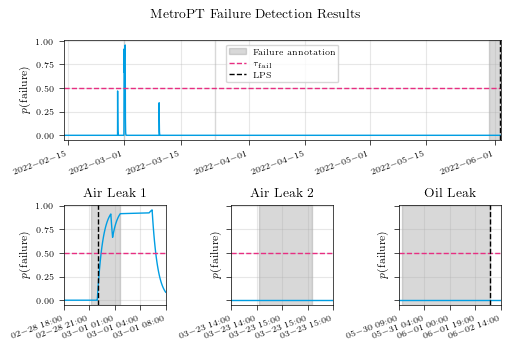

In [68]:

from plotz import COLORS, default_plot_mosaic
import matplotlib.dates as mdates

feature_names = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Flowmeter', 'Motor_current', 'COMP']

actual_failures = [
    (np.datetime64('2022-02-28T21:53:00'), np.datetime64('2022-03-01T02:00:00')),
    (np.datetime64('2022-03-23T14:54:00'), np.datetime64('2022-03-23T15:24:00')),
    (np.datetime64('2022-05-30T12:00:00'), np.datetime64('2022-06-02T06:18:00')),
]

mosaic = '''
AAA
BCD
'''
fig, axs = default_plot_mosaic(width_fraction=1, height_fraction=1.1, sharey=True, subplots=mosaic, style='jdsa')
plt.rcParams.update({'date.autoformatter.hour': '%m-%d %H:00'})

rot = 20

failure_strings = ['Air Leak 1', 'Air Leak 2', 'Oil Leak']
lps_signals = [
    np.datetime64('2022-02-28T22:50:00'),
    None,
    np.datetime64('2022-06-02T06:18:00'),
]

from matplotlib.ticker import MaxNLocator

for idx, ax_string in enumerate(axs):
    ax = axs[ax_string]
    for idx2, (start, end) in enumerate(actual_failures):
        ax.axvspan(start, end, color='grey', alpha=0.3, label='Failure annotation' if idx == 0 and idx2 == 0 else '')

    corr_fail = idx-1
    if corr_fail >= 0:
        ax.set_title(f'{failure_strings[corr_fail]}')
        if corr_fail == 0:
            diff_start = np.timedelta64(1, 'h')
            diff_stop = np.timedelta64(5, 'h')
        elif corr_fail == 1:
            diff_start = np.timedelta64(10, 'm')
            diff_stop = np.timedelta64(10, 'm')
        else:
            diff_start = np.timedelta64(1, 'h')
            diff_stop = np.timedelta64(1, 'h')
        xlim_start = actual_failures[corr_fail][0] - diff_start
        xlim_end = actual_failures[corr_fail][1] + diff_stop
        ax.set_xlim(xlim_start, xlim_end)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:00'))
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    
    ax.plot(test_chunk_dates[:, 1], output, color='C1', label='' if idx == 0 else '')
    ax.axhline(y=0.5, color=COLORS.red, linestyle='--', label=r'$\tau_{\textrm{fail}}$' if idx==0 else '')
    ax.set_ylabel(r'$p(\textrm{failure})$')

    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=rot, ha='right')

    lps_signal = lps_signals[idx-1]
    if lps_signal is not None:
        ax.axvline(x=lps_signal, color='black', linestyle='--', label='LPS' if idx == 0 else '')

axs['A'].set_xlim(np.datetime64('2022-02-14T00:00:00'), np.datetime64('2022-06-02T12:00:00'))
axs['A'].legend()
fig.suptitle('MetroPT Failure Detection Results')
fig.tight_layout()
fig.savefig('plots/pt1_failure_detection_results.pdf', transparent=True, bbox_inches='tight')